# 🔍 Chinook Database EDA using Pandas and Matplotlib

### Connecting to sqlite database

In [97]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('resources/Chinook.db')

### Importing the tables containing data to pandas

In [98]:
# Get list of all table names
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", 
    conn
)['name'].tolist()

print(tables)
# ['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice',
#  'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']

['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']


### Gathering data into pandas dataframes

In [99]:
dfs = {}
for table in tables:
    query = f"SELECT * FROM {table}"      # e.g. "SELECT * FROM Album"
    dfs[table] = pd.read_sql(query, conn)  # load it, store it under that name

### Printing top 5 rows from each table

In [100]:
for df in dfs.keys():
    print(df,"Table","\n")
    print(dfs[df].head(),"\n")
    print("=====================================================================================================","\n")

Album Table 

   AlbumId                                  Title  ArtistId
0        1  For Those About To Rock We Salute You         1
1        2                      Balls to the Wall         2
2        3                      Restless and Wild         2
3        4                      Let There Be Rock         1
4        5                               Big Ones         3 


Artist Table 

   ArtistId               Name
0         1              AC/DC
1         2             Accept
2         3          Aerosmith
3         4  Alanis Morissette
4         5    Alice In Chains 


Customer Table 

   CustomerId  FirstName     LastName  \
0           1       Luís    Gonçalves   
1           2     Leonie       Köhler   
2           3   François     Tremblay   
3           4      Bjørn       Hansen   
4           5  František  Wichterlová   

                                            Company  \
0  Embraer - Empresa Brasileira de Aeronáutica S.A.   
1                                            

### Gathering basic info of each table

In [101]:
for df in dfs.keys():
    print(df,"Table","\n")
    print(dfs[df].info(),"\n")
    print("=====================================================================================================","\n")

Album Table 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   AlbumId   347 non-null    int64 
 1   Title     347 non-null    object
 2   ArtistId  347 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 8.3+ KB
None 


Artist Table 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ArtistId  275 non-null    int64 
 1   Name      275 non-null    object
dtypes: int64(1), object(1)
memory usage: 4.4+ KB
None 


Customer Table 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CustomerId    59 non-null     int64 
 1   FirstName     59 non-null     object
 2   LastName    

### Getting the statistical data for each table

In [102]:
for df in dfs.keys():
    print(df,"Table","\n")
    print(dfs[df].describe(),"\n")
    print("=====================================================================================================","\n")

Album Table 

          AlbumId    ArtistId
count  347.000000  347.000000
mean   174.000000  121.942363
std    100.314505   77.793131
min      1.000000    1.000000
25%     87.500000   58.000000
50%    174.000000  112.000000
75%    260.500000  179.500000
max    347.000000  275.000000 


Artist Table 

         ArtistId
count  275.000000
mean   138.000000
std     79.529869
min      1.000000
25%     69.500000
50%    138.000000
75%    206.500000
max    275.000000 


Customer Table 

       CustomerId  SupportRepId
count   59.000000     59.000000
mean    30.000000      3.949153
std     17.175564      0.818403
min      1.000000      3.000000
25%     15.500000      3.000000
50%     30.000000      4.000000
75%     44.500000      5.000000
max     59.000000      5.000000 


Employee Table 

       EmployeeId  ReportsTo
count     8.00000   7.000000
mean      4.50000   2.857143
std       2.44949   2.193063
min       1.00000   1.000000
25%       2.75000   1.500000
50%       4.50000   2.000000
75%  

### Total revenue of the store

In [103]:
total_revenue = dfs['Invoice']['Total'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $2,328.60


### Number of customers by country

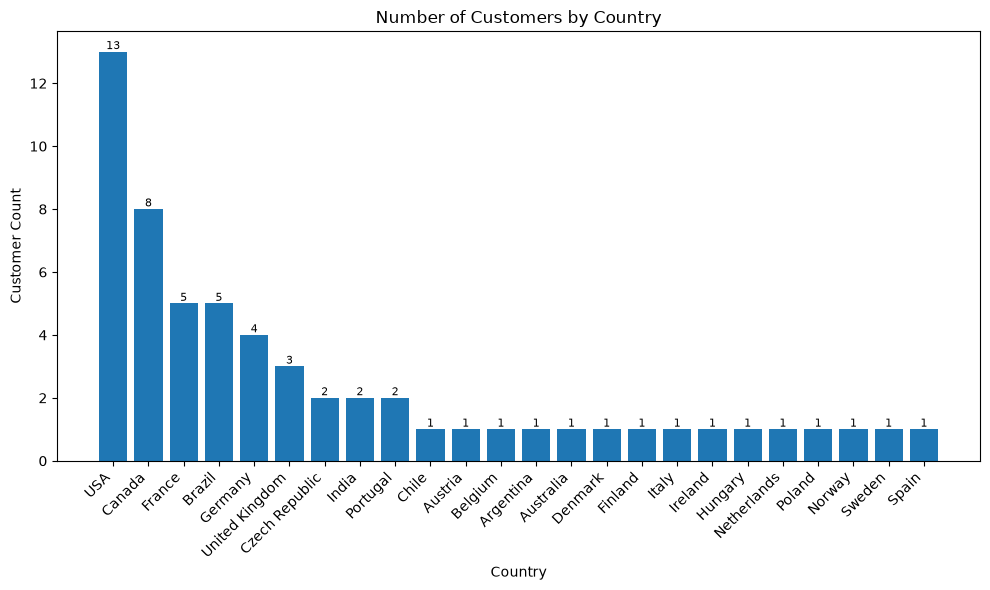

In [104]:
customer_counts = dfs['Customer'].groupby('Country').size().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

bars = plt.bar(customer_counts.index, customer_counts.values)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height()}",
        ha='center',
        va='bottom',
        fontsize=8
)

plt.title('Number of Customers by Country')
plt.xlabel('Country')
plt.ylabel('Customer Count')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

### Revenue by country

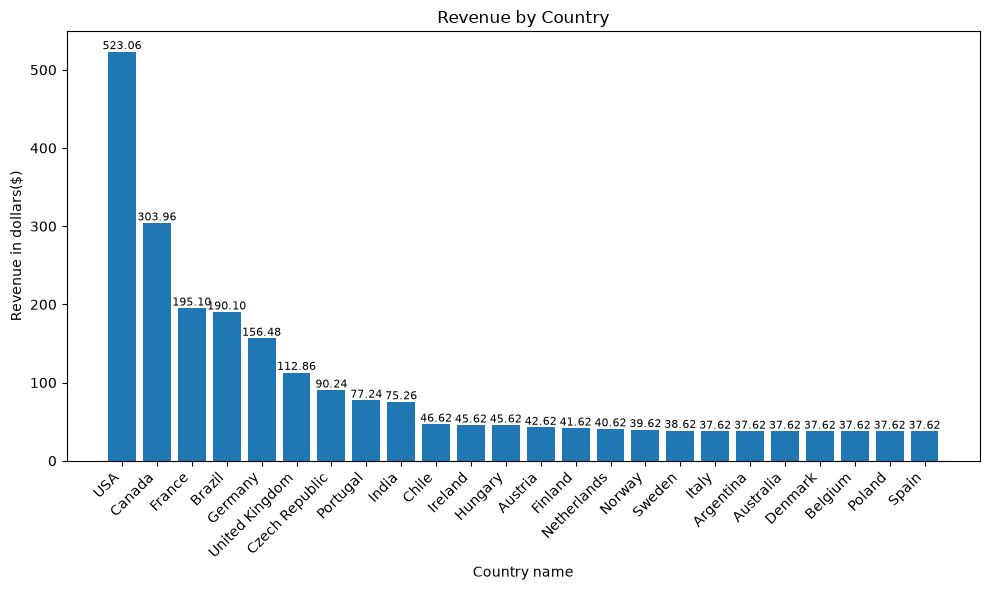

In [105]:
revenue = dfs['Invoice'].groupby('BillingCountry')['Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

bars = plt.bar(revenue.index, revenue.values)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha='center',
        va='bottom',
        fontsize=8
)

plt.title("Revenue by Country")
plt.xlabel("Country name")
plt.ylabel("Revenue in dollars($)")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Revenue share by country

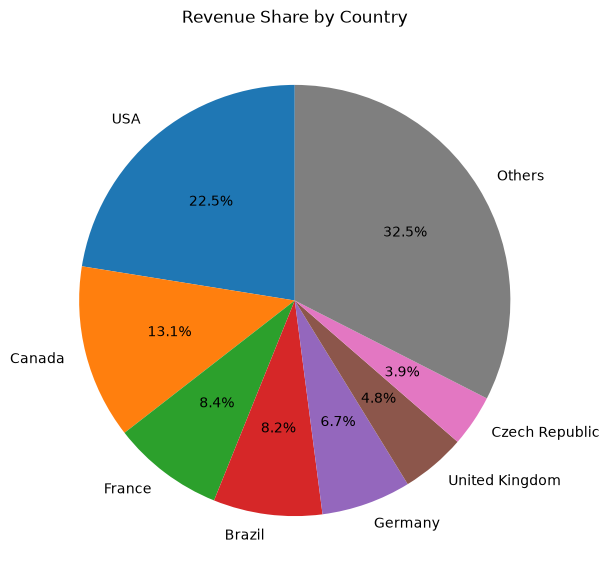

In [106]:
revenue = dfs['Invoice'].groupby('BillingCountry')['Total'].sum().sort_values(ascending=False)

top = revenue.head(7)
top["Others"] = revenue.iloc[7:].sum()

plt.figure(figsize=(7,7))
plt.pie(top, labels=top.index, autopct='%1.1f%%', startangle=90)
plt.title("Revenue Share by Country")
plt.show()

### Revenue by Media type

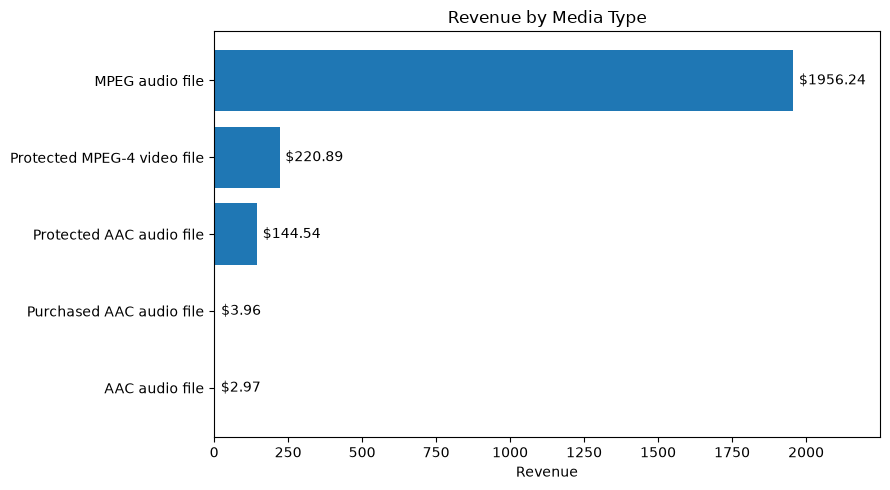

In [107]:
# Merge InvoiceLine with Track
merged = pd.merge(
    dfs['InvoiceLine'],
    dfs['Track'],
    on='TrackId'
)

# Merge with MediaType
merged = pd.merge(
    merged,
    dfs['MediaType'],
    on='MediaTypeId'
)

# Calculate Revenue
merged['Revenue'] = merged['UnitPrice_x'] * merged['Quantity']

# Revenue by Media Type
media_revenue = (
    merged.groupby('Name_y')['Revenue']
    .sum()
    .sort_values()
)


plt.figure(figsize=(9,5))

bars = plt.barh(media_revenue.index, media_revenue.values)

# Add revenue values at the end of each bar
for bar in bars:
    plt.text(
        bar.get_width() + media_revenue.max() * 0.01,
        bar.get_y() + bar.get_height()/2,
        f"${bar.get_width():.2f}",
        va='center'
    )

plt.title("Revenue by Media Type")
plt.xlabel("Revenue")
plt.xlim(0, media_revenue.max() * 1.15)

plt.tight_layout()
plt.show()

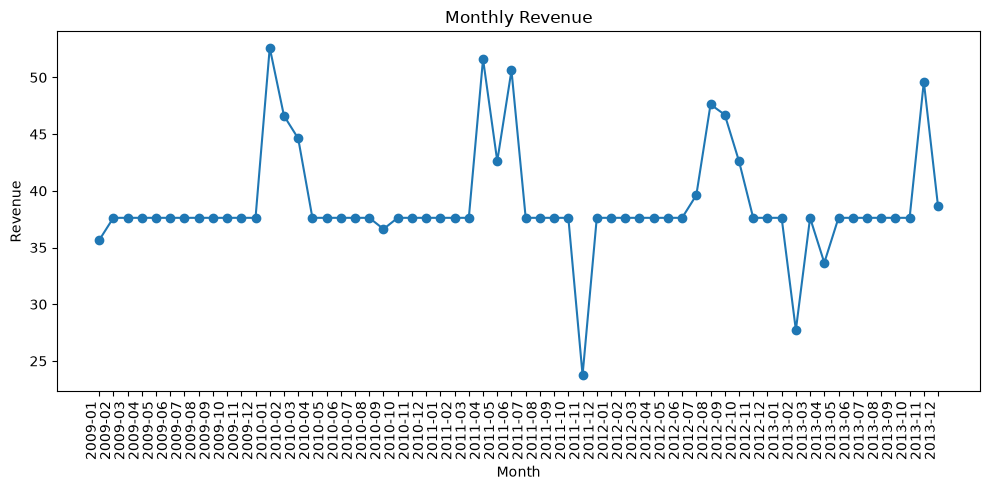

In [108]:
invoice = dfs['Invoice'].copy()
invoice['InvoiceDate'] = pd.to_datetime(invoice['InvoiceDate'])

monthly = (
    invoice
    .groupby(invoice['InvoiceDate'].dt.to_period('M'))['Total']
    .sum()
)

monthly.index = monthly.index.astype(str)

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, marker='o')

plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

### Revenue by genre and country

In [111]:
# Add Invoice table (for BillingCountry)
merged = merged.merge(
    dfs['Invoice'][['InvoiceId', 'BillingCountry']],
    on='InvoiceId'
)

# Add Genre table (for Genre Name)
merged = merged.merge(
    dfs['Genre'],
    on='GenreId'
)

In [116]:
top_countries = (
    merged.groupby('BillingCountry')['Revenue']
    .sum()
    .nlargest(10)
    .index
)

top_genres = (
    merged.groupby('Name')['Revenue']
    .sum()
    .nlargest(10)
    .index
)

pivot = (
    merged[
        (merged['BillingCountry'].isin(top_countries)) &
        (merged['Name'].isin(top_genres))
    ]
    .pivot_table(
        index='Name',
        columns='BillingCountry',
        values='Revenue',
        aggfunc='sum',
        fill_value=0
    )
)

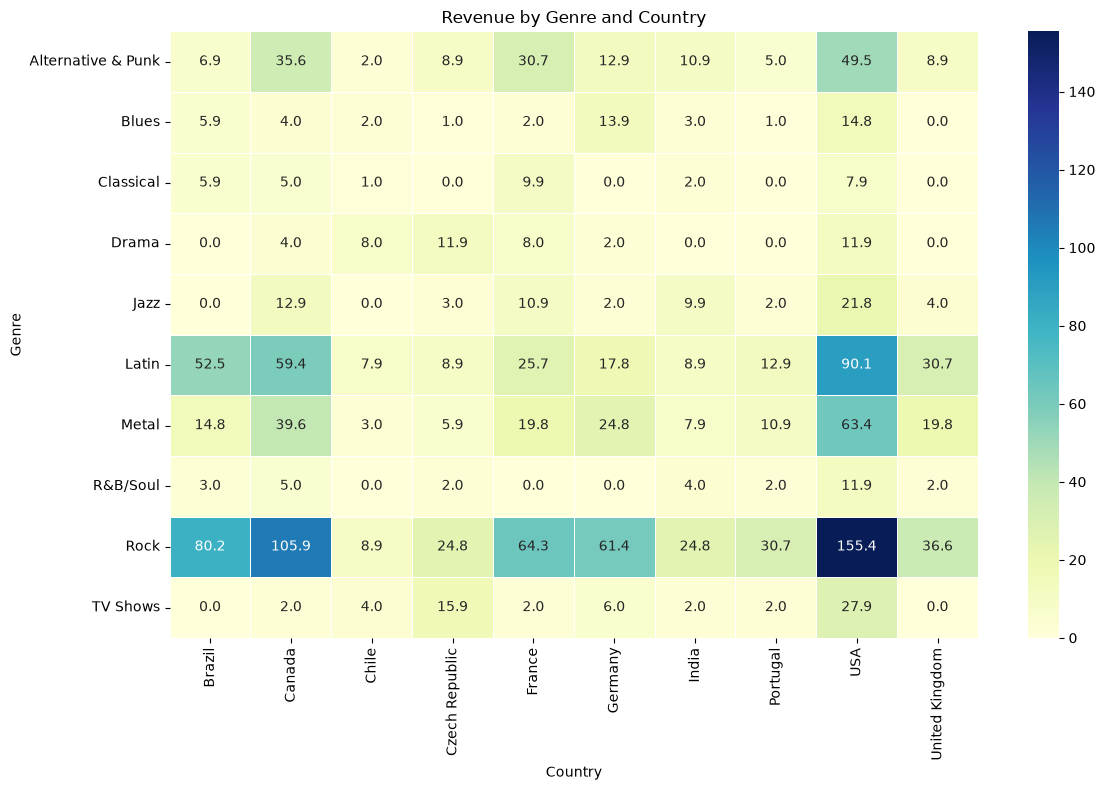

In [117]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    pivot,
    cmap='YlGnBu',
    annot=True,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Revenue by Genre and Country")
plt.xlabel("Country")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()